Ergebnisse visualisieren

Imports

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Plots

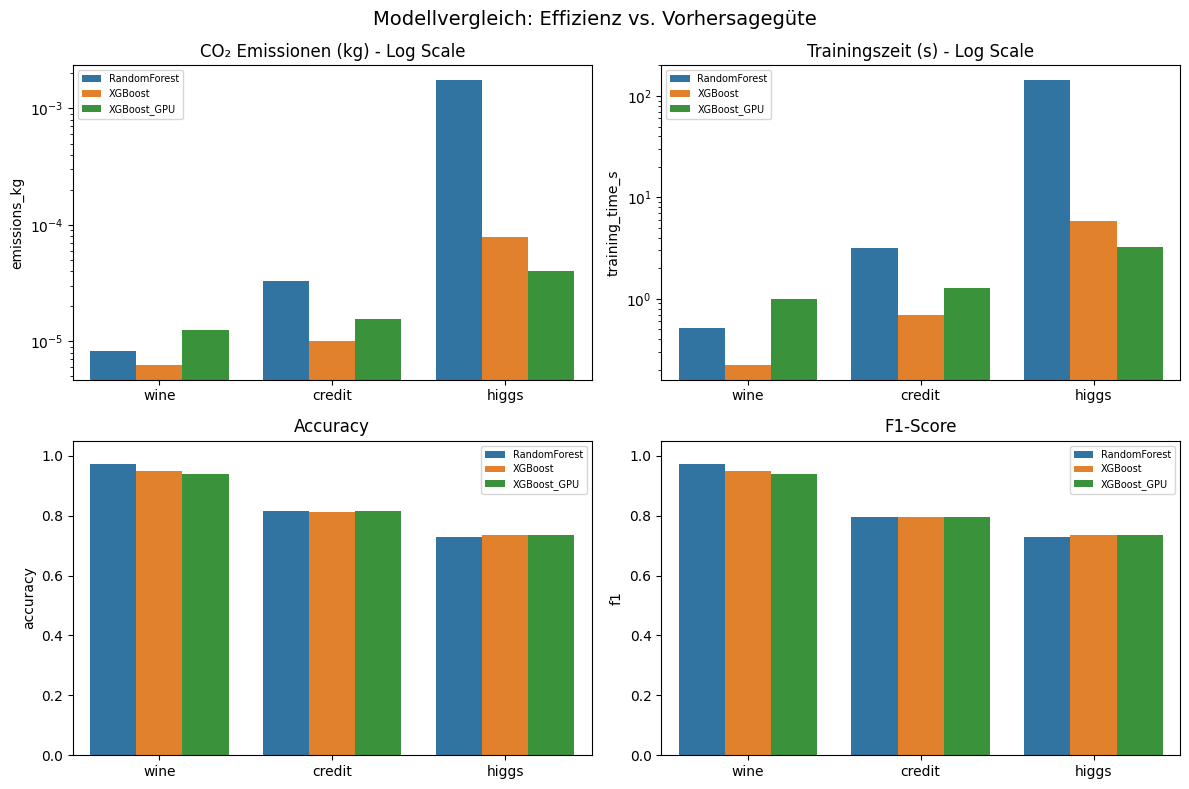

In [ ]:
# 1. Daten einlesen & bereinigen
df = pd.read_csv("../results/results.csv")
df = df.drop_duplicates(subset=["dataset", "model"], keep="first")

# 2. Visualisierung aufbauen
# Die Figure etwas größer machen (14, 10), damit die Zahlen gut Platz haben
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Modellvergleich: Effizienz vs. Vorhersagegüte", fontsize=16)

# Oben Links: Emissionen
sns.barplot(data=df, x="dataset", y="emissions_kg", hue="model", ax=axes[0,0])
axes[0,0].set_title("CO₂ Emissionen (kg) - Log Scale")
axes[0,0].set_yscale("log")
axes[0,0].set_xlabel("")

# Oben Rechts: Trainingszeit
sns.barplot(data=df, x="dataset", y="training_time_s", hue="model", ax=axes[0,1])
axes[0,1].set_title("Trainingszeit (s) - Log Scale")
axes[0,1].set_yscale("log")
axes[0,1].set_xlabel("")

# Unten Links: Accuracy
sns.barplot(data=df, x="dataset", y="accuracy", hue="model", ax=axes[1,0])
axes[1,0].set_title("Accuracy")
# Etwas mehr Platz nach oben (1.15 statt 1.05), damit die Text-Labels nicht den Rand berühren
axes[1,0].set_ylim(0, 1.15) 
axes[1,0].set_xlabel("")

# Unten Rechts: F1-Score
sns.barplot(data=df, x="dataset", y="f1", hue="model", ax=axes[1,1])
axes[1,1].set_title("F1-Score")
axes[1,1].set_ylim(0, 1.15) 
axes[1,1].set_xlabel("")

# 3. ABSOLUTE ZAHLEN HINZUFÜGEN
# Iteriert über alle 4 Subplots und fügt die Zahlen über den Balken ein
for ax in axes.flat:
    for container in ax.containers:
        # fmt='%.3g' formatiert die Zahlen elegant (z.B. 0.00213 oder 0.952)
        # padding=3 sorgt für einen kleinen Abstand zwischen Balken und Zahl
        ax.bar_label(container, fmt='%.3g', padding=3, fontsize=9)

plt.tight_layout()

# Legenden anpassen
for ax in axes.flat:
    ax.legend(fontsize=8, title_fontsize=8)

# Speichern und anzeigen
plt.savefig("../results/vergleich.png", dpi=150, bbox_inches="tight")
plt.show()